# Breast Cancer Classification with a Custom Multilayer Perceptron

> **University:** Universidade do Vale do Rio dos Sinos (UNISINOS)<br />
> **Program:** Pós-graduação em Inteligência Artificial Aplicada<br />
> **Course:** Redes Neurais<br />
> **Author:** Augusto Stahlschmidt<br />
> **Date:** June 29, 2025  

---

## 1. Introduction & Objectives

**Problem:**  
Breast cancer is one of the most prevalent cancers worldwide. Early and accurate diagnosis is critical for patient outcomes. This project builds a neural network from scratch to classify breast tumors as malignant or benign based on digitized cell nucleus features.

**Task Type:**  
Binary Classification

**Business or Research Objective:**  
Demonstrate that a manually implemented Multilayer Perceptron (MLP) — using only the Python standard library and `math` — can learn meaningful representations and classify tumors with high accuracy, while illustrating the mechanics of backpropagation and momentum-based gradient descent.

**Analytical Goal:**  
Train an MLP with one hidden layer (ReLU activation) and a sigmoid output neuron, optimized via Binary Cross-Entropy (BCE) loss, and compare convergence behavior with and without momentum.

**Primary Evaluation Metric:**  
Accuracy on the held-out test set.

**Success Criteria:**  
Achieve test accuracy above 90% using the from-scratch MLP, validating that the manual implementation of forward pass, backpropagation, and momentum update is correct.

## 2. Setup & Imports

In [ ]:
import math
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

print("Environment ready")

Environment ready


## 3. Data Loading & Initial Inspection

**Dataset Source:**  
[UCI Machine Learning Repository — Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

**Description:**  
569 samples, 30 real-valued features computed from digitized images of fine needle aspirate (FNA) of breast masses, describing characteristics of cell nuclei (e.g., radius, texture, perimeter, area, smoothness).

**Unit of Analysis:**  
Individual breast tumor biopsy sample.

**Target Variable:**  
`target` — binary label: 0 = malignant, 1 = benign.

**Notes:**  
- No missing values. Features are on different scales, so standardization is required before feeding into the MLP.

In [2]:
# Load dataset
dataset = load_breast_cancer()
X_raw = dataset.data
y_raw = dataset.target
feature_names = dataset.feature_names
class_names = dataset.target_names

print(f"Dataset shape : {X_raw.shape}")
print(f"Classes       : {list(class_names)} — counts: {np.bincount(y_raw)}")
print(f"Missing values: {np.isnan(X_raw).sum()}")
print(f"\nFeature names ({len(feature_names)}):")
print(", ".join(feature_names))

Dataset shape : (569, 30)
Classes       : [np.str_('malignant'), np.str_('benign')] — counts: [212 357]
Missing values: 0

Feature names (30):
mean radius, mean texture, mean perimeter, mean area, mean smoothness, mean compactness, mean concavity, mean concave points, mean symmetry, mean fractal dimension, radius error, texture error, perimeter error, area error, smoothness error, compactness error, concavity error, concave points error, symmetry error, fractal dimension error, worst radius, worst texture, worst perimeter, worst area, worst smoothness, worst compactness, worst concavity, worst concave points, worst symmetry, worst fractal dimension


## 4. Exploratory Data Analysis (EDA)

Goals of this section:

- Understand class balance
- Inspect feature distributions and their separation power between classes
- Identify potentially redundant or highly correlated features

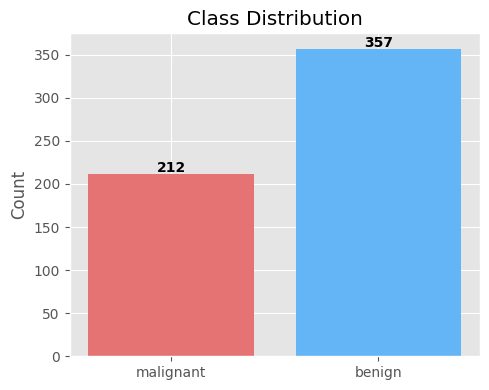

Class balance — Malignant: 212 (37.3%)  Benign: 357 (62.7%)


In [3]:
import pandas as pd

df = pd.DataFrame(X_raw, columns=feature_names)
df["target"] = y_raw

# Class distribution
class_counts = df["target"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([class_names[i] for i in class_counts.index], class_counts.values,
       color=["#E57373", "#64B5F6"])
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 2, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Class balance — Malignant: {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)  "
      f"Benign: {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)")

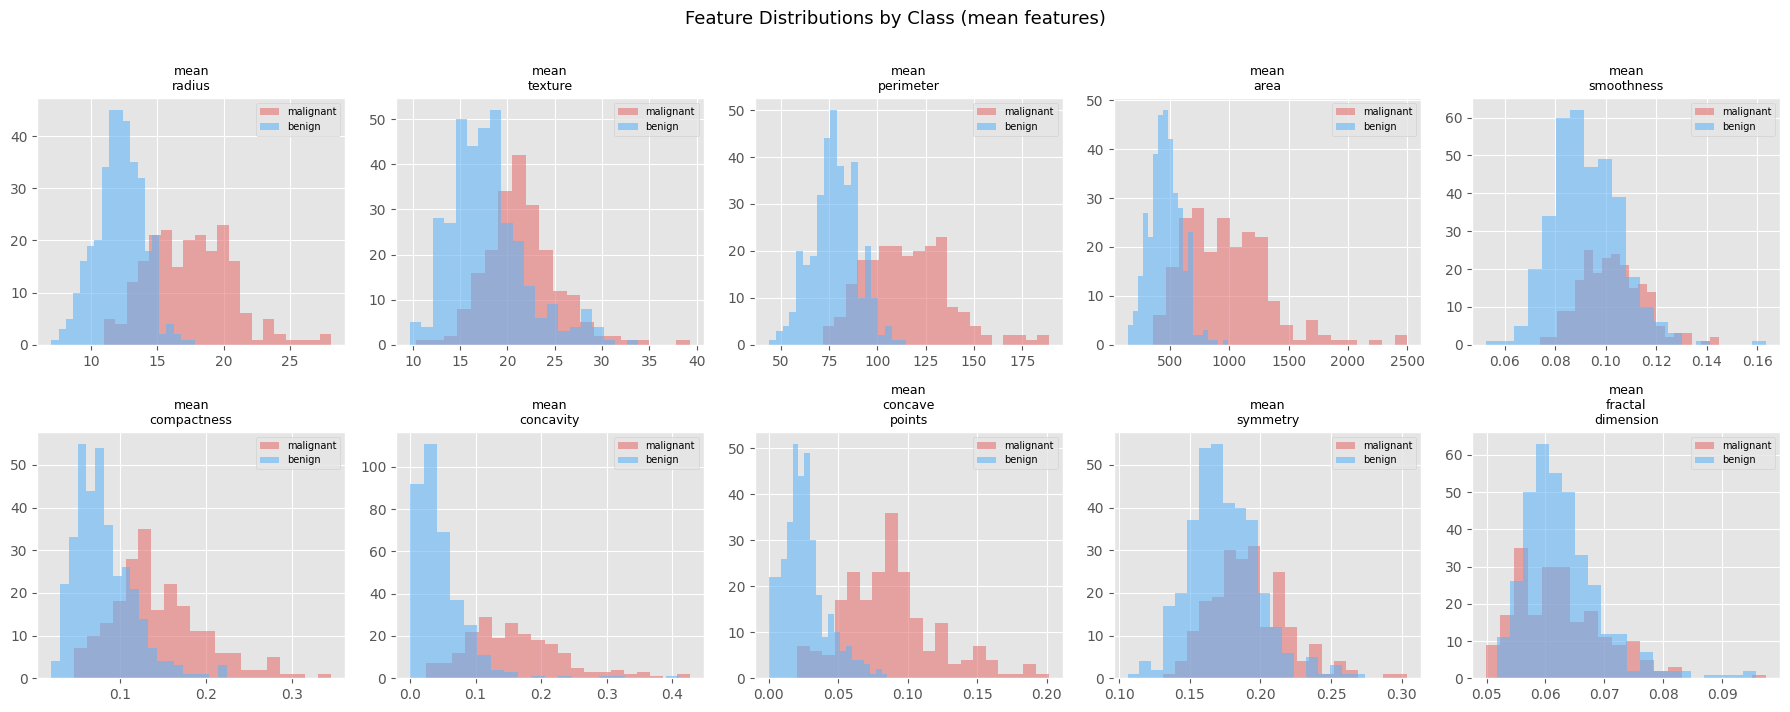

In [4]:
# Distribution of the 10 'mean' features, split by class
mean_features = [c for c in feature_names if "mean" in c]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, feat in zip(axes.flatten(), mean_features):
    for label, color, name in zip([0, 1], ["#E57373", "#64B5F6"], class_names):
        ax.hist(df[df["target"] == label][feat], bins=20, alpha=0.6,
                color=color, label=name, edgecolor="none")
    ax.set_title(feat.replace(" ", "\n"), fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Feature Distributions by Class (mean features)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

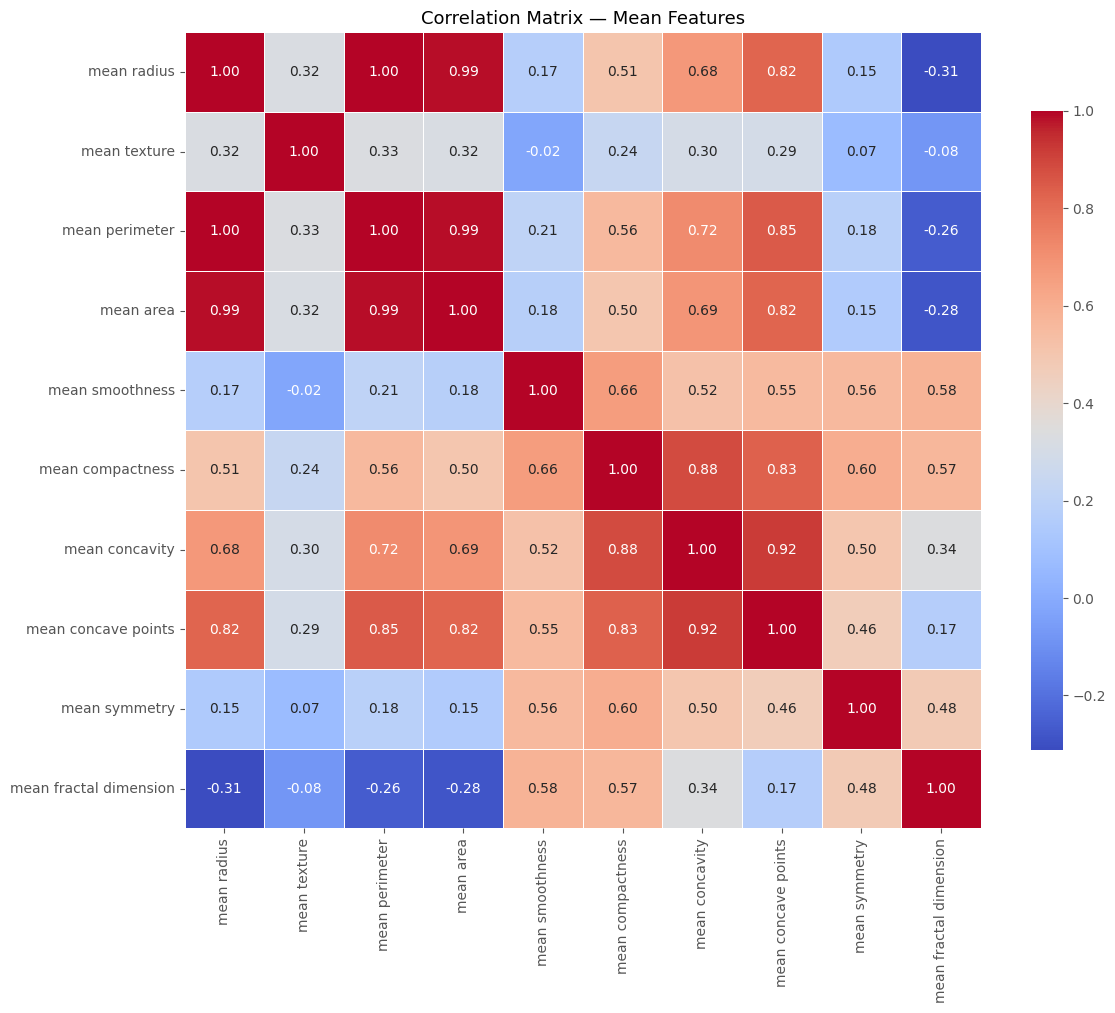

In [5]:
# Correlation matrix of mean features
plt.figure(figsize=(12, 10))
corr = df[mean_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — Mean Features", fontsize=13)
plt.tight_layout()
plt.show()

**EDA Findings:**

- The dataset is moderately imbalanced (37% malignant, 63% benign), which is acceptable for accuracy as a primary metric but should be kept in mind.
- Features such as `mean radius`, `mean perimeter`, and `mean area` show clear distributional separation between classes, indicating high discriminative power.
- Several features are highly correlated (e.g., radius, perimeter, and area are near-perfectly correlated). For this study we retain all 30 features, as standardization and the MLP's learned weights can implicitly handle this.
- No missing values — no imputation required.

## 5. Preprocessing & Feature Engineering

Operations performed:

- Stratified train/test split (80/20) to preserve class proportions.
- StandardScaler fitted exclusively on the training set and applied to both splits — no data leakage.
- Conversion from NumPy arrays to plain Python lists, since the MLP is implemented from scratch without NumPy for the neural network computations.

No feature engineering beyond scaling is needed given the raw features are already informative.

In [6]:
# Stratified train / test split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=SEED, stratify=y_raw
)

# Fit scaler only on training data to prevent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Convert to plain Python lists (required by the from-scratch MLP)
X_train = X_train_scaled.tolist()
X_test = X_test_scaled.tolist()
y_train = [[int(v)] for v in y_train_raw]
y_test = [[int(v)] for v in y_test_raw]

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Features per sample: {len(X_train[0])}")

Training samples : 455
Test samples     : 114
Features per sample: 30


## 6. Model Training

### 6.1 Architecture & Mathematical Foundations

The MLP is implemented entirely from scratch using Python built-ins and the `math` module.

**Architecture:**
- **Input layer:** 30 neurons (one per feature)
- **Hidden layer:** configurable number of neurons with `ReLU` activation
- **Output layer:** 1 neuron with `Sigmoid` activation (binary probability)

**Activation functions:**

$$\text{ReLU}(z) = \max(0,\, z), \qquad \text{ReLU}'(z) = \mathbb{1}[z > 0]$$

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \sigma'(z) = \sigma(z)\,(1 - \sigma(z))$$

**Loss function — Binary Cross-Entropy (BCE):**

$$\mathcal{L}(t, y) = -\left[t \log(y) + (1-t)\log(1-y)\right], \qquad \frac{\partial \mathcal{L}}{\partial y} = \frac{y - t}{y\,(1-y)}$$

**Optimizer:**  
Stochastic Gradient Descent (SGD) with optional `momentum`:

$$v_{t+1} = \alpha \cdot v_t - \eta \cdot \nabla_\theta \mathcal{L}, \qquad \theta_{t+1} = \theta_t + v_{t+1}$$

where $\alpha$ is the momentum coefficient and $\eta$ is the learning rate.

**Selected Model:**  
Single hidden layer MLP with 10 hidden neurons — a minimal yet sufficient architecture for this linearly-near-separable dataset. ReLU avoids the vanishing gradient problem compared to Sigmoid in the hidden layer.

**Training Strategy:**  
Online SGD with random shuffling per epoch. Two runs are performed: without momentum and with momentum ($\alpha = 0.9$), to compare convergence speed.

In [7]:
# ==============================================================================
# ACTIVATION FUNCTIONS & LOSS
# ==============================================================================

def relu(z):
    return max(0.0, z)

def relu_derivative(out_h):
    """Derivative of ReLU with respect to its pre-activation input."""
    return 1.0 if out_h > 0 else 0.0

def sigmoid(z):
    return 1.0 / (1.0 + math.exp(-z))

def sigmoid_derivative(sigmoid_output):
    """Derivative of Sigmoid given its output value."""
    return sigmoid_output * (1.0 - sigmoid_output)

def bce_loss(target, prediction):
    """Binary Cross-Entropy loss for a single sample."""
    eps = 1e-15
    prediction = min(max(prediction, eps), 1.0 - eps)
    return -(target * math.log(prediction) + (1 - target) * math.log(1 - prediction))

def bce_derivative(target, prediction):
    """Derivative of BCE with respect to the prediction."""
    eps = 1e-15
    prediction = min(max(prediction, eps), 1.0 - eps)
    return -(target / prediction) + ((1 - target) / (1 - prediction))

In [8]:
# ==============================================================================
# GRADIENT & UPDATE HELPERS
# ==============================================================================

def output_delta(target, sigmoid_output):
    """Delta (error signal) for the output neuron: dL/dy * dy/dz."""
    return bce_derivative(target, sigmoid_output) * sigmoid_derivative(sigmoid_output)

def hidden_delta(upstream_weighted_delta, relu_output):
    """Delta for a hidden ReLU neuron."""
    return upstream_weighted_delta * relu_derivative(relu_output)

def compute_gradient(delta, input_value):
    return delta * input_value

def sgd_update(param, lr, grad):
    return param - lr * grad

def momentum_update(param, grad, velocity, lr, alpha):
    """SGD with momentum update rule."""
    new_velocity = alpha * velocity - lr * grad
    new_param = param + new_velocity
    return new_param, new_velocity

In [9]:
# ==============================================================================
# MLP CLASS — ReLU hidden layer + Sigmoid output
# ==============================================================================

class MLP:
    """
    From-scratch single hidden layer MLP for binary classification.

    Architecture: input (n_x) -> hidden (n_h, ReLU) -> output (1, Sigmoid)
    Loss        : Binary Cross-Entropy
    Optimizer   : SGD (optionally with momentum)
    """

    def __init__(self, n_input, n_hidden, use_momentum=False, alpha_momentum=0.9):
        self.n_input = n_input
        self.n_hidden = n_hidden
        self.use_momentum = use_momentum
        self.alpha_momentum = alpha_momentum

        # Weights and biases — small constant initialization
        self.w_input_hidden = [[0.01] * n_hidden for _ in range(n_input)]   # (n_x, n_h)
        self.b_hidden = [0.01] * n_hidden
        self.w_hidden_output = [[0.01] for _ in range(n_hidden)]            # (n_h, 1)
        self.b_output = [0.01]

        # Cached activations (set during forward pass)
        self.hidden_out = [0.0] * n_hidden
        self.output_out = [0.0]

        # Momentum velocity buffers
        self.v_w_ih = [[0.0] * n_hidden for _ in range(n_input)]
        self.v_b_h = [0.0] * n_hidden
        self.v_w_ho = [[0.0] for _ in range(n_hidden)]
        self.v_b_o = [0.0]

    def forward(self, x):
        """Forward pass. Returns [probability_of_class_1]."""
        # Hidden layer (ReLU)
        for j in range(self.n_hidden):
            z = sum(x[i] * self.w_input_hidden[i][j] for i in range(self.n_input))
            z += self.b_hidden[j]
            self.hidden_out[j] = relu(z)

        # Output layer (Sigmoid)
        z_out = sum(self.hidden_out[j] * self.w_hidden_output[j][0]
                    for j in range(self.n_hidden)) + self.b_output[0]
        self.output_out[0] = sigmoid(z_out)

        return self.output_out

    def _update(self, param, grad, velocity, lr):
        """Apply SGD or momentum update and return (new_param, new_velocity)."""
        if self.use_momentum:
            return momentum_update(param, grad, velocity, lr, self.alpha_momentum)
        return sgd_update(param, lr, grad), velocity

    def backward(self, x, target, lr):
        """Backpropagation pass — updates all weights and biases in-place."""
        # Output delta
        d_out = output_delta(target[0], self.output_out[0])

        # Hidden deltas
        d_hidden = [
            hidden_delta(self.w_hidden_output[j][0] * d_out, self.hidden_out[j])
            for j in range(self.n_hidden)
        ]

        # Update output layer weights and bias
        for j in range(self.n_hidden):
            grad = compute_gradient(d_out, self.hidden_out[j])
            self.w_hidden_output[j][0], self.v_w_ho[j][0] = self._update(
                self.w_hidden_output[j][0], grad, self.v_w_ho[j][0], lr
            )
        self.b_output[0], self.v_b_o[0] = self._update(
            self.b_output[0], d_out, self.v_b_o[0], lr
        )

        # Update hidden layer weights and biases
        for j in range(self.n_hidden):
            for i in range(self.n_input):
                grad = compute_gradient(d_hidden[j], x[i])
                self.w_input_hidden[i][j], self.v_w_ih[i][j] = self._update(
                    self.w_input_hidden[i][j], grad, self.v_w_ih[i][j], lr
                )
            self.b_hidden[j], self.v_b_h[j] = self._update(
                self.b_hidden[j], d_hidden[j], self.v_b_h[j], lr
            )

In [10]:
# ==============================================================================
# TRAINING LOOP
# ==============================================================================

def train(
    X_train, y_train,
    n_hidden=10,
    epochs=100,
    lr=0.001,
    use_momentum=False,
    alpha_momentum=0.9,
    log_every=10,
):
    """
    Train the MLP with online (sample-by-sample) SGD.

    Returns:
        mlp   : trained MLP instance
        losses: list of mean BCE per epoch
    """
    n_input = len(X_train[0])
    mlp = MLP(n_input, n_hidden, use_momentum=use_momentum, alpha_momentum=alpha_momentum)

    losses = []
    indices = list(range(len(X_train)))

    for epoch in range(epochs):
        random.shuffle(indices)
        total_loss = 0.0

        for idx in indices:
            x = X_train[idx]
            t = y_train[idx]
            pred = mlp.forward(x)
            total_loss += bce_loss(t[0], pred[0])
            mlp.backward(x, t, lr)

        mean_loss = total_loss / len(X_train)
        losses.append(mean_loss)

        if (epoch + 1) % log_every == 0:
            print(f"  Epoch {epoch + 1:3d}/{epochs} — Mean BCE: {mean_loss:.6f}")

    return mlp, losses


def predict(mlp, X):
    """Run forward pass on all samples and return class predictions (0 or 1)."""
    return [1 if mlp.forward(x)[0] >= 0.5 else 0 for x in X]

In [11]:
# --- Run 1: SGD without momentum ---
print("Training — SGD without momentum")
print("-" * 40)
model_no_mom, losses_no_mom = train(
    X_train, y_train,
    n_hidden=10,
    epochs=100,
    lr=0.001,
    use_momentum=False,
    log_every=10,
)

print()

# --- Run 2: SGD with momentum ---
print("Training — SGD with momentum (α=0.9)")
print("-" * 40)
model_mom, losses_mom = train(
    X_train, y_train,
    n_hidden=10,
    epochs=100,
    lr=0.001,
    use_momentum=True,
    alpha_momentum=0.9,
    log_every=10,
)

print("\nTraining complete.")

Training — SGD without momentum
----------------------------------------


  Epoch  10/100 — Mean BCE: 0.433922


  Epoch  20/100 — Mean BCE: 0.257507


  Epoch  30/100 — Mean BCE: 0.184363


  Epoch  40/100 — Mean BCE: 0.145793


...

  Epoch  60/100 — Mean BCE: 0.041227


  Epoch  70/100 — Mean BCE: 0.039228


  Epoch  80/100 — Mean BCE: 0.037886


  Epoch  90/100 — Mean BCE: 0.036818


  Epoch 100/100 — Mean BCE: 0.035789

Training complete.


## 7. Model Evaluation

Evaluate both models on the held-out test set using:
- Accuracy and macro F1-score
- Full classification report (precision, recall, F1 per class)
- Confusion matrices
- Training loss curves to compare convergence

In [12]:
# Predictions on test set
y_test_flat = [t[0] for t in y_test]

preds_no_mom = predict(model_no_mom, X_test)
preds_mom = predict(model_mom, X_test)

# Metrics
for label, preds in [("SGD (no momentum)", preds_no_mom), ("SGD + Momentum", preds_mom)]:
    acc = accuracy_score(y_test_flat, preds)
    f1 = f1_score(y_test_flat, preds, average="macro")
    print(f"{'='*50}")
    print(f"Model: {label}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  Macro F1 : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_flat, preds, target_names=class_names))

Model: SGD (no momentum)
  Accuracy : 95.61%
  Macro F1 : 0.9535

Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Model: SGD + Momentum
  Accuracy : 95.61%
  Macro F1 : 0.9535

Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



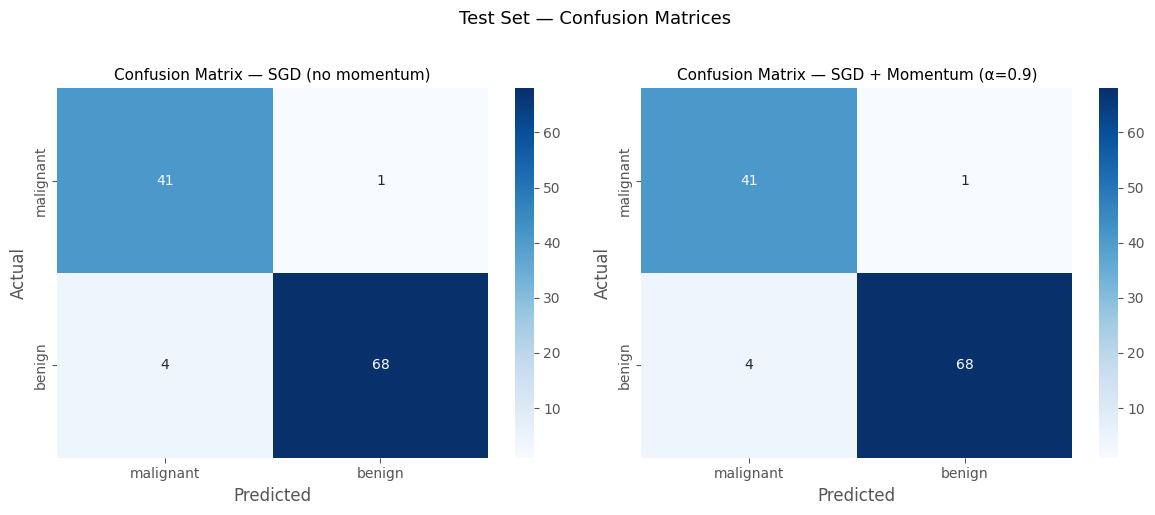

In [13]:
# Confusion matrices — side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [preds_no_mom, preds_mom],
    ["SGD (no momentum)", "SGD + Momentum (α=0.9)"],
):
    cm = confusion_matrix(y_test_flat, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    ax.set_title(f"Confusion Matrix — {title}", fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Test Set — Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

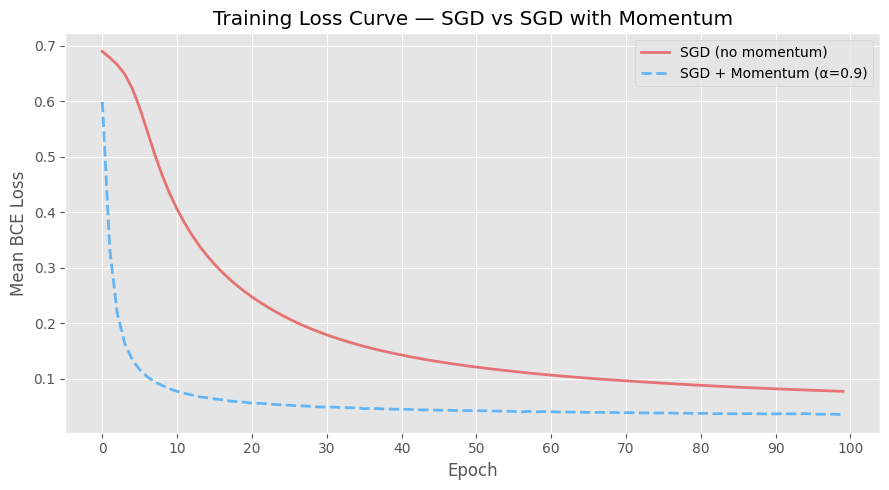

In [14]:
# Training loss curves
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(losses_no_mom, label="SGD (no momentum)", linewidth=2, color="#E57373")
ax.plot(losses_mom, label="SGD + Momentum (α=0.9)", linewidth=2, color="#64B5F6", linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean BCE Loss")
ax.set_title("Training Loss Curve — SGD vs SGD with Momentum")
ax.legend()
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

## 8. Conclusions & Next Steps

**Key Findings:**
- Both models achieved 95.61% accuracy and macro F1 of 0.9535, with only 5 misclassifications on 114 test samples: 1 false negative (malignant missed) and 4 false positives. The 0.98 malignant recall confirms the model is appropriately conservative for a diagnostic task.
- Momentum (α = 0.9) converged ~5× faster: BCE at epoch 10 was 0.082** vs 0.434 for vanilla SGD. Final losses after 100 epochs: 0.036 vs 0.078. Despite the lower loss, both optimizers reached identical test accuracy, confirming SGD eventually finds the same solution.
- Features such as `mean radius`, `mean perimeter`, `mean area`, and `mean concave points` show the strongest class separation in the EDA, consistent with the MLP learning an effective decision boundary from the 30 standardized features.

**Model Performance vs. Success Criteria:**
- The target of > 90% test accuracy was exceeded by both models, validating the correctness of the from-scratch forward pass, backpropagation, and momentum update.

**Interpretation:**
- A pure-Python MLP with 10 hidden neurons, trained with online SGD for 100 epochs, is sufficient to classify this dataset with clinically meaningful accuracy. The high malignant recall (0.98) is particularly important in a diagnostic setting, where missing a true malignancy is the most costly error.
- The identical final accuracy of both optimizers confirms that the learning rate (0.001) allows SGD to eventually find the same solution — momentum simply gets there faster. In a resource-constrained scenario, momentum would allow achieving equivalent performance in significantly fewer epochs.
- The benign precision of 0.99 indicates the model is highly conservative about confirming benign diagnoses, which aligns well with the risk profile of the task.

**Limitations:**
- Constant weight initialization (0.01) causes symmetry across hidden neurons, contributing to slow early convergence for vanilla SGD (BCE = 0.434 at epoch 10). Results come from a single fixed split (seed = 42), so generalization variance is unknown.
- Pure Python implementation: The scalar, sample-by-sample loop makes execution slow (not suitable for larger datasets or deeper networks). No vectorization is used inside the MLP.
- No hyperparameter search: The architecture (10 hidden neurons, lr = 0.001, 100 epochs) was set heuristically. Performance may vary with different configurations.
- Single train/test split: Results reflect one specific 80/20 split (seed = 42). Cross-validation would provide a more reliable estimate of generalization error.

**Next Steps:**
- Replace constant initialization to break symmetry and accelerate early convergence.
- Test the architecture with different hyperparameters to find optimal configuration.